Dieser Codeblock stellt ein **experimentelles Test- und Analyse-Framework für synthetische Datengenerierung und Drift-Prüfung** bereit:

- definiert mehrere **Drift-Metriken** zum Vergleich von realen und synthetischen Daten, z. B. **KS-Test, FDR-korrigierte p-Werte, PSI, Wasserstein-Distanz, Energy Distance, MMD, Korrelationsdrift** und einen **Origin-Detektor per AUC**,
- bietet **Visualisierungen** zum direkten Verteilungsvergleich einzelner Features,
- prüft die **Plausibilität synthetischer Daten** über einfache Regelwerke und Grenzen,
- implementiert mehrere **Augmentierungsverfahren** für Trainingsdaten, darunter:
  - **clusterbasierte Augmentierung**,
  - **clusterbasierte Augmentierung mit zusätzlichem Rauschen**,
  - **Mittelwertbildung zwischen Samples innerhalb von Gruppen**,
  - sowie **Copula-basierte Augmentierung** mit **Gaussian- oder t-Copula** und **Shrinkage-Kovarianz**,
- und stellt Wrapper bereit, um synthetische Daten **klassenproportional bis zu einer Zielgröße** zu erzeugen.

Ziel ist ein **Testgelände für Datenaugmentation**, in dem sowohl die **Erzeugung** als auch die **Qualitäts- und Driftbewertung** synthetischer Daten systematisch geprüft werden können.

In [2]:
# === Setup / Gemeinsame Funktionen für alle Zellen ===
import os, time, warnings
import numpy as np
import pandas as pd

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial.distance import cdist, pdist, squareform

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


# ---------------------------
# Helpers
# ---------------------------
def _bh_fdr(pvals: np.ndarray):
    """Benjamini–Hochberg FDR-Korrektur. Rückgabe: q-Values (gleiche Reihenfolge)."""
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    # ensure monotonicity
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = q
    return np.minimum(out, 1.0)


def _psi(x_base: np.ndarray, x_new: np.ndarray, n_bins: int = 10, eps: float = 1e-6):
    """
    Population Stability Index (PSI), Bins nach Baseline-Quantilen.
    """
    x_base = np.asarray(x_base, dtype=float)
    x_new = np.asarray(x_new, dtype=float)
    x_base = x_base[~np.isnan(x_base)]
    x_new = x_new[~np.isnan(x_new)]
    if x_base.size < 5 or x_new.size < 5:
        return np.nan
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(x_base, qs))
    if edges.size < 3:
        return np.nan
    base_hist, _ = np.histogram(x_base, bins=edges)
    new_hist, _ = np.histogram(x_new, bins=edges)
    base_prop = base_hist / max(base_hist.sum(), 1)
    new_prop  = new_hist  / max(new_hist.sum(), 1)
    base_prop = np.clip(base_prop, eps, None)
    new_prop  = np.clip(new_prop,  eps, None)
    return float(np.sum((new_prop - base_prop) * np.log(new_prop / base_prop)))


def _wasserstein_over_iqr(x_base: np.ndarray, x_new: np.ndarray):
    w = stats.wasserstein_distance(x_base[~np.isnan(x_base)], x_new[~np.isnan(x_new)])
    iqr = np.subtract(*np.nanpercentile(x_base, [75, 25]))
    scale = iqr if iqr > 0 else np.nanstd(x_base)
    return np.nan if (scale is None or scale == 0) else float(w / scale)


def _safe_numeric(df: pd.DataFrame, exclude=()):
    num = df.select_dtypes(include=[np.number]).copy()
    for col in exclude:
        if col in num.columns:
            num.drop(columns=[col], inplace=True)
    return num


# ---------------------------
# 1) Univariate: Kennzahlen + KS + FDR
# ---------------------------
def univariate_drift_metrics(X_real: pd.DataFrame,
                             X_synth: pd.DataFrame,
                             exclude=("Verletzungsstatus",),
                             n_bins_psi: int = 10) -> pd.DataFrame:
    """
    Liefert pro Feature: KS, q (FDR), SMD, Var-Ratio, PSI, Wasserstein/IQR, ΔMedian.
    """
    A = _safe_numeric(X_real, exclude)
    B = _safe_numeric(X_synth, exclude)
    common = [c for c in A.columns if c in B.columns]
    rows = []
    pvals = []
    for col in common:
        a = A[col].to_numpy(dtype=float)
        b = B[col].to_numpy(dtype=float)
        a = a[~np.isnan(a)]
        b = b[~np.isnan(b)]
        if a.size < 5 or b.size < 5:
            rows.append(dict(feature=col, ks=np.nan, p=np.nan, smd=np.nan,
                             var_ratio=np.nan, psi=np.nan, w_over_iqr=np.nan,
                             d_median=np.nan))
            pvals.append(np.nan)
            continue
        ks_stat, p = stats.ks_2samp(a, b, alternative="two-sided", mode="auto")
        smd = (np.nanmean(b) - np.nanmean(a)) / (np.nanstd(a, ddof=1) + 1e-12)
        var_ratio = (np.nanvar(b, ddof=1) + 1e-12) / (np.nanvar(a, ddof=1) + 1e-12)
        psi = _psi(a, b, n_bins=n_bins_psi)
        w_iqr = _wasserstein_over_iqr(a, b)
        d_med = float(np.nanmedian(b) - np.nanmedian(a))
        rows.append(dict(feature=col, ks=ks_stat, p=p, smd=smd,
                         var_ratio=var_ratio, psi=psi, w_over_iqr=w_iqr,
                         d_median=d_med))
        pvals.append(p)
    df = pd.DataFrame(rows)
    if len(df) and np.isfinite(df["p"]).any():
        df["q_fdr"] = _bh_fdr(df["p"].fillna(1.0).to_numpy())
    else:
        df["q_fdr"] = np.nan
    return df.sort_values(["q_fdr", "ks"], ascending=[True, False])


# ---------------------------
# 2) Verteilungsplots (Overlay)
# ---------------------------

def plot_feature_overlay(X_real: pd.DataFrame,
                         X_synth: pd.DataFrame,
                         feature: str,
                         bins: int = 40):
    """
    Overlay: Histogramm + einfache KDE (Real vs. Synth).
    - Dichtevergleich (density=True), aber Labels zeigen n (Stichprobengröße).
    - Speichert nichts, zeigt direkt und schließt danach die Figure (Ausgabe bleibt sichtbar).
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy import stats

    if feature not in X_real.columns or feature not in X_synth.columns:
        print(f"[plot] {feature} nicht in beiden DataFrames.")
        return

    a = X_real[feature].dropna().to_numpy(dtype=float)
    b = X_synth[feature].dropna().to_numpy(dtype=float)
    if a.size < 5 or b.size < 5:
        print(f"[plot] zu wenig Daten in {feature}")
        return

    data_min = np.nanmin(np.concatenate([a, b]))
    data_max = np.nanmax(np.concatenate([a, b]))

    fig, ax = plt.subplots(figsize=(7, 4.2))
    # Variante C: density=True + n im Label
    ax.hist(a, bins=bins, alpha=0.45, density=True, label=f"Real (n={len(a)})",  edgecolor="none")
    ax.hist(b, bins=bins, alpha=0.45, density=True, label=f"Synth (n={len(b)})", edgecolor="none")

    # einfache KDE (ebenfalls Dichte)
    try:
        kde_a = stats.gaussian_kde(a)
        kde_b = stats.gaussian_kde(b)
        xs = np.linspace(data_min, data_max, 300)
        ax.plot(xs, kde_a(xs), lw=1.4, label="Real KDE")
        ax.plot(xs, kde_b(xs), lw=1.4, label="Synth KDE")
    except Exception:
        pass

    ax.set_title(f"Distribution Overlay – {feature}")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()

    plt.show()
    plt.close(fig)  # Figure schließen (Ausgabe bleibt im Notebook sichtbar)


# ---------------------------
# 3) Multivariat – kompakt (ein Zahlenfaktor + Korrelation)
# ---------------------------
def energy_distance_multivariate(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",)):
    """
    Energy Distance zwischen zwei multivariaten Samples (kleiner ist ähnlicher).
    """
    A = _safe_numeric(X_real, exclude).to_numpy(dtype=float)
    B = _safe_numeric(X_synth, exclude).to_numpy(dtype=float)
    A = A[~np.any(np.isnan(A), axis=1)]
    B = B[~np.any(np.isnan(B), axis=1)]
    if len(A) < 3 or len(B) < 3:
        return np.nan
    # E = 2 E||X-Y|| - E||X-X'|| - E||Y-Y'||
    d_xy = cdist(A, B, metric="euclidean")
    d_xx = pdist(A, metric="euclidean")
    d_yy = pdist(B, metric="euclidean")
    return float(2 * d_xy.mean() - d_xx.mean() - d_yy.mean())


def mmd_rbf(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",), gamma="median"):
    """
    Maximum Mean Discrepancy (RBF). Größer = stärkerer Drift.
    """
    A = _safe_numeric(X_real, exclude).to_numpy(dtype=float)
    B = _safe_numeric(X_synth, exclude).to_numpy(dtype=float)
    A = A[~np.any(np.isnan(A), axis=1)]
    B = B[~np.any(np.isnan(B), axis=1)]
    if len(A) < 3 or len(B) < 3:
        return np.nan
    Z = np.vstack([A, B])
    if gamma == "median":
        d2 = squareform(pdist(Z, metric="sqeuclidean"))
        med = np.median(d2[d2 > 0])
        gam = 1.0 / (med + 1e-12)
    else:
        gam = float(gamma)
    def _k(X, Y):  # RBF kernel
        return np.exp(-gam * cdist(X, Y, metric="sqeuclidean"))
    Kxx = _k(A, A); Kyy = _k(B, B); Kxy = _k(A, B)
    n = A.shape[0]; m = B.shape[0]
    # Unbiased estimator
    term_x = (np.sum(Kxx) - np.trace(Kxx)) / (n*(n-1))
    term_y = (np.sum(Kyy) - np.trace(Kyy)) / (m*(m-1))
    term_xy = (2 * np.sum(Kxy)) / (n*m)
    return float(term_x + term_y - term_xy)


def correlation_drift(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",)):
    """
    Liefert: Frobenius-Norm der ΔKorrelation (skaliert), #Sign-Flips, Top-Δr-Paare.
    """
    A = _safe_numeric(X_real, exclude)
    B = _safe_numeric(X_synth, exclude)
    common = [c for c in A.columns if c in B.columns]
    A = A[common]; B = B[common]
    if A.shape[0] < 5 or B.shape[0] < 5:
        return dict(fro_norm=np.nan, sign_flips=np.nan, top_pairs=[])
    R1 = A.corr().fillna(0.0).to_numpy()
    R2 = B.corr().fillna(0.0).to_numpy()
    D = R2 - R1
    p = R1.shape[0]
    fro = np.linalg.norm(D, ord="fro") / np.sqrt(p*p)  # skaliert [0..]
    # Sign-Flips nur oberes Dreieck (ohne Diagonale)
    mask = np.triu(np.ones_like(R1, dtype=bool), 1)
    flips = np.sum((np.sign(R1[mask]) * np.sign(R2[mask])) == -1)
    # Top-Paare
    idxs = np.argpartition(np.abs(D[mask]), -10)[-10:]
    absD = np.abs(D[mask]).flatten()
    order = idxs[np.argsort(-absD[idxs])]
    top_pairs = []
    # rekonstruiere Paare:
    ii, jj = np.where(mask)
    for k in order:
        i, j = ii[k], jj[k]
        top_pairs.append((common[i], common[j], float(D[i, j])))
    return dict(fro_norm=float(fro), sign_flips=int(flips), top_pairs=top_pairs)


# ---------------------------
# 4) Downstream – ein Faktor (AUC eines Origin-Detektors)
# ---------------------------
def origin_discriminability_auc(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",), cv=5, random_state=42):
    """
    Trainiert LR, die 'Origin' (real=0, synth=1) unterscheiden soll. AUC nahe 0.5 = gut.
    """
    A = _safe_numeric(X_real, exclude).to_numpy(dtype=float)
    B = _safe_numeric(X_synth, exclude).to_numpy(dtype=float)
    A = A[~np.any(np.isnan(A), axis=1)]
    B = B[~np.any(np.isnan(B), axis=1)]
    n = min(len(A), len(B))
    if n < 20:
        return np.nan
    # balancieren
    rng = np.random.default_rng(random_state)
    A = A[rng.choice(len(A), n, replace=False)]
    B = B[rng.choice(len(B), n, replace=False)]
    X = np.vstack([A, B])
    y = np.array([0]*n + [1]*n)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    aucs = []
    for tr, te in skf.split(X, y):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr]); Xte = scaler.transform(X[te])
        clf = LogisticRegression(max_iter=500, n_jobs=None)
        clf.fit(Xtr, y[tr])
        p = clf.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[te], p))
    return float(np.mean(aucs))


# ---------------------------
# 5) Plausibilitäts-Checks (einfach & konfigurierbar)
# ---------------------------
def plausibility_report(df: pd.DataFrame,
                        bounds: dict = None,
                        nonneg_patterns=("force", "moment", "impulse", "time", "rsi", "stiff", "rate"),
                        angle_patterns=("angle",),
                        angle_bounds=(-180, 180)):
    """
    bounds: dict {'FeatureName': (min,max)} – harte Grenzen.
    *_patterns: lower-case Substrings für Heuristiken.
    Rückgabe: dict mit Counts & Liste verletzter Felder.
    """
    bad_cells = []
    n = len(df)
    cols = df.select_dtypes(include=[np.number]).columns
    # harte Grenzen
    if bounds:
        for col, (mn, mx) in bounds.items():
            if col in df.columns:
                v = df[col].to_numpy(dtype=float)
                mask = (~np.isnan(v)) & ((v < mn) | (v > mx))
                bad = int(mask.sum())
                if bad:
                    bad_cells.append((col, f"bounds[{mn},{mx}]", bad))
    # nonnegativ
    for col in cols:
        name = col.lower()
        if any(k in name for k in nonneg_patterns):
            v = df[col].to_numpy(dtype=float)
            bad = int(np.sum(v[~np.isnan(v)] < 0))
            if bad:
                bad_cells.append((col, "nonneg", bad))
    # Winkel
    if angle_bounds is not None:
        mn, mx = angle_bounds
        for col in cols:
            name = col.lower()
            if any(k in name for k in angle_patterns):
                v = df[col].to_numpy(dtype=float)
                mask = (~np.isnan(v)) & ((v < mn) | (v > mx))
                bad = int(mask.sum())
                if bad:
                    bad_cells.append((col, f"angle[{mn},{mx}]", bad))
    total_bad = sum(b for _, _, b in bad_cells) if bad_cells else 0
    return dict(total_rows=n, total_violations=total_bad, details=bad_cells)


# ---------------------------
# Augmentierung (nur Gruppierung nach 'Verletzungsstatus')
# ---------------------------
def perform_clustering(X_sub, max_clusters=4):
    cols = [c for c in X_sub.columns if c != "Verletzungsstatus"]
    X_num = X_sub[cols]
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7, cov_jitter=1e-6):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.atleast_2d(np.var(cluster_data.values.flatten(), ddof=0))
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cov = np.asarray(cov, dtype=float)
        cov += np.eye(cov.shape[0]) * (cov_jitter * (np.trace(cov) / max(cov.shape[0], 1) + 1e-12))
        cluster_params[cl_id] = (mu, cov, cols)

    for _, row in X_sub.iterrows():
        new_row = row.copy()
        for _, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)
    if "Verletzungsstatus" in augmented_df.columns:
        augmented_df["Verletzungsstatus"] = augmented_df["Verletzungsstatus"].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [g for _, g in df_train.groupby(["Verletzungsstatus"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [c for c in df_noisy.select_dtypes(include=['float64', 'int64']).columns if c != "Verletzungsstatus"]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, (std if np.isfinite(std) else 0.0) * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group); half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise  = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [g for _, g in df_train.groupby(["Verletzungsstatus"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    group_df = group_df.reset_index(drop=True)
    if len(group_df) < 2: return None
    numeric_cols = [col for col in group_df.columns if col != "Verletzungsstatus"]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    new_group_samples = []
    for i in range(group_new_samples):
        s1 = group_df.iloc[pairs[i, 0]]
        s2 = group_df.iloc[pairs[i, 1]]
        mean_sample = s1.copy()
        for col in numeric_cols:
            mean_sample[col] = (s1[col] + s2[col]) / 2
        mean_sample["Verletzungsstatus"] = s1["Verletzungsstatus"]
        new_group_samples.append(mean_sample)
    return pd.DataFrame(new_group_samples) if new_group_samples else None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby("Verletzungsstatus")
    total_original = len(df_train)
    total_new = int(total_original * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_props = group_sizes / total_original
    tasks = []
    for injury_status, group_df in groups:
        group_new = int(total_new * group_props.loc[injury_status])
        tasks.append((group_df, group_new))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new) for group_df, group_new in tasks
    )
    augmented_groups = [g for g in augmented_groups if g is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1, return_synth=False):
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1) if N > 0 else 0
    augmentation_factor = 1 + (per_method_needed / N) if N > 0 else 1.0

    if verbose:
        print(f"[Aug] target_size={target_size} | N={N} | per_method_needed={per_method_needed}")

    funcs_and_params = [
        (augment_training_data_cluster,       {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means,         {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs if n_jobs != -1 else 3))(
        delayed(lambda f, p: f(X_train, y_train, **p))(func, params) for func, params in funcs_and_params
    )
    X_aug_cluster,       y_aug_cluster       = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means,   y_aug_group_means   = results[2]

    def subsample(X_aug, y_aug, required):
        if required <= 0: 
            return X_aug.iloc[[]], y_aug.iloc[[]]
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug.reset_index(drop=True), y_aug.reset_index(drop=True)

    X_aug_cluster,       y_aug_cluster       = subsample(X_aug_cluster,       y_aug_cluster,       per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means,   y_aug_group_means   = subsample(X_aug_group_means,   y_aug_group_means,   per_method_needed)

    X_synth = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_synth = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)

    X_total = pd.concat([X_train.reset_index(drop=True), X_synth], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_synth], axis=0).reset_index(drop=True)

    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)

    if verbose:
        print(f"[Aug] done: final={len(X_total)} | synth_added={len(X_synth)} | {(time.time()-start_time):.2f}s")

    if return_synth:
        return X_total, y_total, X_synth, y_synth
    return X_total, y_total


import numpy as np, pandas as pd
from scipy.stats import norm, chi2, t
from sklearn.covariance import LedoitWolf

# --- Shrinkage-Helper ------------------------------------------
def shrink_cov(Sigma, lam: float = 0.10):
    """
    Ridge-/Targeted-Shrinkage Richtung (avg_var * I).
    lam in [0,1]; 0.05–0.15 ist oft gut bei p >> n.
    """
    p = Sigma.shape[0]
    avg_var = np.trace(Sigma) / max(p, 1)
    Sigma_s = (1 - lam) * Sigma + lam * (avg_var * np.eye(p))
    return 0.5 * (Sigma_s + Sigma_s.T)

# --- t-Copula-Sampler (liefert Uniforms U) ----------------------
def sample_t_copula(mu, Sigma, n, nu=6, rng=None):
    """
    Multivariate t (df=nu) via Scale-Mixture; Rückgabe als Uniforms (t-CDF).
    """
    rng = np.random.default_rng(rng)
    p = Sigma.shape[0]
    Z = rng.multivariate_normal(np.zeros(p), Sigma, size=n)     # ~ N(0, Sigma)
    w = chi2.rvs(df=nu, size=n, random_state=rng) / nu          # ~ Chi2/nu
    T = mu + Z / np.sqrt(w)[:, None]                            # ~ t_nu(mu, Sigma)
    U = t.cdf(T, df=nu)                                         # komponentenweise CDF → U(0,1)
    return U

# --- Copula-Augmenter mit Shrinkage + t-Option -----------
def gaussian_copula_augment(
    X_sub: pd.DataFrame,
    n_new: int,
    random_state=None,
    *,
    model: str = "gaussian",   # "gaussian" oder "t"
    lam: float = 0.10,         # Shrinkage-Intensität
    nu: int = 6                # df für t-Copula (falls model="t")
) -> pd.DataFrame:
    """
    Augmentiert X_sub per Copula:
      - bewahrt empirische Marginals (pro Feature)
      - bewahrt rangbasierte Abhängigkeiten (mit Shrinkage-Kovarianz)
    model: "gaussian" (Default) oder "t"
    """
    rng = np.random.default_rng(random_state)

    # nur numerische Spalten
    Xn = X_sub.select_dtypes(include=[np.number])
    cols = Xn.columns.tolist()
    if len(cols) == 0 or len(Xn) < 2 or n_new <= 0:
        return pd.DataFrame(columns=Xn.columns)

    # Rang -> Uniform(0,1)  (empirische CDF)
    U = Xn.rank(pct=True, method='average').to_numpy()
    U = np.clip(U, 1e-6, 1 - 1e-6)

    # Uniform -> Z-Raum (Standardnormal)
    Z = norm.ppf(U)

    # Kovarianz im Z-Raum + Shrinkage + Jitter
    lw = LedoitWolf().fit(Z)
    mu = Z.mean(axis=0)
    Sigma = lw.covariance_.copy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = shrink_cov(Sigma, lam=lam)                 # <-- NEU: Shrinkage anwenden
    Sigma += np.eye(Sigma.shape[0]) * 1e-6

    # Ziehen im Copula-Raum → Uniforms U_new
    if model == "t":
        U_new = sample_t_copula(mu, Sigma, n_new, nu=nu, rng=rng)
    else:
        Z_new = rng.multivariate_normal(mu, Sigma, size=n_new)
        U_new = norm.cdf(Z_new)

    # inverse Marginals (empirische Quantile), konstante Spalten handhaben
    X_new = np.empty_like(U_new)
    Xv = Xn.to_numpy()
    for j, col in enumerate(cols):
        col_vals = Xv[:, j]
        if not np.isfinite(col_vals).all():
            col_vals = np.nan_to_num(col_vals, nan=np.nanmedian(col_vals))
        if np.nanstd(col_vals) < 1e-12:
            X_new[:, j] = col_vals[0]        # konstant lassen
        else:
            X_new[:, j] = np.quantile(col_vals, U_new[:, j])
    return pd.DataFrame(X_new, columns=cols)

# --- ERWEITERT: Trainer-Wrapper reicht Parameter durch --------------
def augment_training_data_copula(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    target_size: int,
    random_state: int | None = None,
    *,
    model: str = "gaussian",   # "gaussian" | "t"
    lam: float = 0.10,
    nu: int = 6
):
    """
    Füllt bis target_size auf – proportional je Klasse.
    Reicht Copula-Parameter durch.
    Rückgabe: (X_total, y_total, X_synth, y_synth)
    """
    df = X_train.copy()
    df["Verletzungsstatus"] = y_train.values
    out_X, out_y = [X_train.reset_index(drop=True)], [y_train.reset_index(drop=True)]

    need_total = max(0, target_size - len(X_train))
    if need_total == 0:
        return out_X[0], out_y[0], X_train.iloc[[]], y_train.iloc[[]]

    grp = df.groupby("Verletzungsstatus")
    props = grp.size() / len(df)

    synth_X_parts, synth_y_parts = [], []
    for cls, g in grp:
        need_cls = int(round(need_total * props.loc[cls]))
        if need_cls <= 0:
            continue
        Xg = g.drop(columns=["Verletzungsstatus"])
        X_new = gaussian_copula_augment(
            Xg, need_cls, random_state=random_state,
            model=model, lam=lam, nu=nu
        )
        y_new = pd.Series([cls] * len(X_new), name="Verletzungsstatus")
        synth_X_parts.append(X_new)
        synth_y_parts.append(y_new)

    X_synth = pd.concat(synth_X_parts, axis=0).reset_index(drop=True) if synth_X_parts else X_train.iloc[[]]
    y_synth = pd.concat(synth_y_parts, axis=0).reset_index(drop=True) if synth_y_parts else y_train.iloc[[]]

    X_total = pd.concat([out_X[0], X_synth], axis=0).reset_index(drop=True)
    y_total = pd.concat([out_y[0], y_synth], axis=0).reset_index(drop=True)

    # Überschuss ggf. aus den synthetischen kürzen
    overshoot = len(X_total) - target_size
    if overshoot > 0 and len(X_synth) > 0:
        idx_keep = np.arange(len(X_synth))
        rng = np.random.default_rng(random_state)
        drop_idx = rng.choice(idx_keep, size=overshoot, replace=False)
        mask = np.ones(len(X_synth), dtype=bool); mask[drop_idx] = False
        X_synth = X_synth.iloc[mask].reset_index(drop=True)
        y_synth = y_synth.iloc[mask].reset_index(drop=True)
        X_total = pd.concat([X_train.reset_index(drop=True), X_synth], axis=0).reset_index(drop=True)
        y_total = pd.concat([y_train.reset_index(drop=True), y_synth], axis=0).reset_index(drop=True)

    return X_total, y_total, X_synth, y_synth

def augment_training_data_copula_full(*args, **kwargs):
    return augment_training_data_copula(*args, **kwargs)





Dieser Codeblock ist ein **reiner Quality Assurance (QA)-Runner zur visuellen und numerischen Prüfung synthetisch augmentierter Daten**, ohne Dateien zu speichern:


- lädt einen Datensatz und erzeugt daraus mit `augment_training_data_combined()` **synthetische Zusatzdaten**,
- vergleicht **reale vs. synthetische Daten getrennt nach Klasse**,
- berechnet **univariate Drift-Metriken** pro Feature, inklusive **KS-Test mit FDR-Korrektur**,
- zeigt für die auffälligsten Features **Overlay-Plots mit Histogramm und KDE**,
- berechnet **multivariate Drift-Metriken** wie **Energy Distance, MMD und Korrelationsdrift**,
- prüft über eine **Origin-AUC**, wie gut reale und synthetische Daten voneinander unterscheidbar sind,
- und gibt am Ende eine **kompakte Zusammenfassung aller QA-Kennzahlen pro Klasse** in der Konsole aus.

Ziel ist eine **schnelle explorative Qualitätskontrolle** der synthetischen Daten direkt im Notebook.

In [19]:
# DISPLAY-ONLY QA RUNNER (ohne Dateien speichern, ohne Plausibility)
import matplotlib.pyplot as plt

def run_qa_for_file_display(
    data_path,
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=12,
    fdr_alpha=0.05,
    show_full_table=False
):
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])

    target_size = int(len(X) * target_augmentation_multiplier)
    _, _, X_synth, y_synth = augment_training_data_combined(
        X, y, target_size=target_size, verbose=False, n_jobs=-1, return_synth=True
    )

    print(f"\n=== QA: {os.path.basename(data_path)} ===")
    print(f"Original N={len(X)}, Synth N={len(X_synth)}, Multiplier≈{target_augmentation_multiplier}")

    summaries = []
    for cls in sorted(y.unique()):
        print(f"\n— Klasse {cls} —")
        X_real_cls  = X[y == cls].copy()
        X_synth_cls = X_synth[y_synth == cls].copy()
        print(f"  n_real={len(X_real_cls)}, n_synth={len(X_synth_cls)}")

        # 1) Univariat (inkl. KS + FDR)
        uv = univariate_drift_metrics(X_real_cls, X_synth_cls, exclude=(target_column,), n_bins_psi=10)
        num_signif = int((uv["q_fdr"] <= fdr_alpha).sum()) if "q_fdr" in uv else 0
        print(f"  Univariate: signif(KS, FDR≤{fdr_alpha}) = {num_signif} / {len(uv)} Features")

        if show_full_table:
            try:
                from IPython.display import display
                display(uv)
            except Exception:
                print(uv.to_string(index=False, max_rows=60))
        else:
            print(uv.sort_values(["q_fdr","ks"], ascending=[True, False]).head(12).to_string(index=False))

        # 2) Verteilungsplots (nur anzeigen)
        feats_to_plot = uv.sort_values(["q_fdr","ks"], ascending=[True, False])["feature"].head(plots_top_n).tolist()
        print(f"  Plots für Top-{len(feats_to_plot)} Features (Overlay Histogramm+KDE):")
        for feat in feats_to_plot:
            plot_feature_overlay(X_real_cls, X_synth_cls, feature=feat)


        # 3) Multivariat (Kompakt + Flip-Prozent)
        E  = energy_distance_multivariate(X_real_cls, X_synth_cls, exclude=(target_column,))
        M  = mmd_rbf(X_real_cls, X_synth_cls, exclude=(target_column,), gamma="median")
        cd = correlation_drift(X_real_cls, X_synth_cls, exclude=(target_column,))
        # Flip-Quote in %
        p_num = X_real_cls.select_dtypes(include=[np.number]).shape[1]
        n_pairs = p_num * (p_num - 1) // 2
        flip_pct = (cd['sign_flips'] / n_pairs * 100.0) if n_pairs > 0 else np.nan
        print(f"  Multivariat: EnergyDist={E:.4f} | MMD={M:.4f} | ΔR_Fro={cd['fro_norm']:.4f} | SignFlips={cd['sign_flips']} ({flip_pct:.1f}%)")

        # 4) Downstream – Origin-AUC + disc
        auc  = origin_discriminability_auc(X_real_cls, X_synth_cls, exclude=(target_column,), cv=5, random_state=42)
        disc = max(auc, 1 - auc) if np.isfinite(auc) else np.nan
        print(f"  Origin AUC (real vs. synth): {auc:.3f}  | disc={disc:.3f}  (ideal: AUC≈0.5, disc≈0.5)")

    

        summaries.append(dict(
            cls=cls,
            n_real=len(X_real_cls),
            n_synth=len(X_synth_cls),
            energy=E,
            mmd=M,
            dR_fro=cd['fro_norm'],
            flips=cd['sign_flips'],
            flips_pct=flip_pct,
            origin_auc=auc,
            origin_disc=disc,
            ks_signif=num_signif,
            n_feat=len(uv)
        ))

    # 5) Konsolen-Zusammenfassung + Legende
    print("\n=== Zusammenfassung (konsole) ===")
    summ_df = pd.DataFrame(summaries)
    print(summ_df.to_string(index=False))

    print("""
── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch).
• ΔR_Fro / SignFlips: Drift der Feature-Korrelationen.
  Ziel: ΔR_Fro klein; SignFlips (Vorzeichenwechsel von r) möglichst wenige.
• Origin AUC / disc: Trennbarkeit real vs. synthetisch (nur QA-Sanity).
  Ideal: AUC ≈ 0.5 und damit disc = max(AUC, 1−AUC) ≈ 0.5.
""")


Dieser Codeblock ist ein **QA-Runner zur Qualitätsprüfung von Copula-basiert erzeugten synthetischen Daten**, ohne Dateien zu speichern:

- lädt einen Datensatz und erzeugt mit `augment_training_data_copula()` **synthetische Zusatzdaten** mittels **Gaussian- oder t-Copula**,
- vergleicht **reale vs. synthetische Daten getrennt nach Klasse**,
- berechnet **univariate Drift-Metriken** pro Feature, inklusive **KS-Test mit FDR-Korrektur**,
- zeigt für die auffälligsten Features **Overlay-Plots mit Histogramm und KDE**,
- berechnet **multivariate Drift-Metriken** wie **Energy Distance, MMD und Korrelationsdrift**,
- prüft über eine **Origin-AUC**, wie gut reale und synthetische Daten voneinander unterscheidbar sind,
- und gibt abschließend eine **kompakte Zusammenfassung aller QA-Kennzahlen pro Klasse** in der Konsole aus.

Der Unterschied zur vorherigen QA-Version ist, dass hier speziell die **Copula-basierte Augmentierung** geprüft wird, statt der kombinierten Augmentierungsmethoden.

In [35]:
# DISPLAY-ONLY QA RUNNER (ohne Dateien speichern, ohne Plausibility)
import matplotlib.pyplot as plt

def run_qa_for_copula(
    data_path,
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=12,
    fdr_alpha=0.05,
    show_full_table=False
):
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])

    target_size = int(len(X) * target_augmentation_multiplier)
    X_total, y_total, X_synth, y_synth = augment_training_data_copula(
        X, y, target_size=target_size,
        random_state=42,
        model="t",   # ← "gaussian" oder "t"
        lam=0.15,    # ← Shrinkage; ggf. 0.05–0.15 testen
        nu=10        # ← df der t-Copula
    )



    print(f"\n=== QA: {os.path.basename(data_path)} ===")
    print(f"Original N={len(X)}, Synth N={len(X_synth)}, Multiplier≈{target_augmentation_multiplier}")

    summaries = []
    for cls in sorted(y.unique()):
        print(f"\n— Klasse {cls} —")
        X_real_cls  = X[y == cls].copy()
        X_synth_cls = X_synth[y_synth == cls].copy()
        print(f"  n_real={len(X_real_cls)}, n_synth={len(X_synth_cls)}")

        # 1) Univariat (inkl. KS + FDR)
        uv = univariate_drift_metrics(X_real_cls, X_synth_cls, exclude=(target_column,), n_bins_psi=10)
        num_signif = int((uv["q_fdr"] <= fdr_alpha).sum()) if "q_fdr" in uv else 0
        print(f"  Univariate: signif(KS, FDR≤{fdr_alpha}) = {num_signif} / {len(uv)} Features")

        if show_full_table:
            try:
                from IPython.display import display
                display(uv)
            except Exception:
                print(uv.to_string(index=False, max_rows=60))
        else:
            print(uv.sort_values(["q_fdr","ks"], ascending=[True, False]).head(12).to_string(index=False))

        # 2) Verteilungsplots (nur anzeigen)
        feats_to_plot = uv.sort_values(["q_fdr","ks"], ascending=[True, False])["feature"].head(plots_top_n).tolist()
        print(f"  Plots für Top-{len(feats_to_plot)} Features (Overlay Histogramm+KDE):")
        for feat in feats_to_plot:
            plot_feature_overlay(X_real_cls, X_synth_cls, feature=feat)


        # 3) Multivariat (Kompakt + Flip-Prozent)
        E  = energy_distance_multivariate(X_real_cls, X_synth_cls, exclude=(target_column,))
        M  = mmd_rbf(X_real_cls, X_synth_cls, exclude=(target_column,), gamma="median")
        cd = correlation_drift(X_real_cls, X_synth_cls, exclude=(target_column,))
        # Flip-Quote in %
        p_num = X_real_cls.select_dtypes(include=[np.number]).shape[1]
        n_pairs = p_num * (p_num - 1) // 2
        flip_pct = (cd['sign_flips'] / n_pairs * 100.0) if n_pairs > 0 else np.nan
        print(f"  Multivariat: EnergyDist={E:.4f} | MMD={M:.4f} | ΔR_Fro={cd['fro_norm']:.4f} | SignFlips={cd['sign_flips']} ({flip_pct:.1f}%)")

        # 4) Downstream – Origin-AUC + disc
        auc  = origin_discriminability_auc(X_real_cls, X_synth_cls, exclude=(target_column,), cv=5, random_state=42)
        disc = max(auc, 1 - auc) if np.isfinite(auc) else np.nan
        print(f"  Origin AUC (real vs. synth): {auc:.3f}  | disc={disc:.3f}  (ideal: AUC≈0.5, disc≈0.5)")

    

        summaries.append(dict(
            cls=cls,
            n_real=len(X_real_cls),
            n_synth=len(X_synth_cls),
            energy=E,
            mmd=M,
            dR_fro=cd['fro_norm'],
            flips=cd['sign_flips'],
            flips_pct=flip_pct,
            origin_auc=auc,
            origin_disc=disc,
            ks_signif=num_signif,
            n_feat=len(uv)
        ))

    # 5) Konsolen-Zusammenfassung + Legende
    print("\n=== Zusammenfassung (konsole) ===")
    summ_df = pd.DataFrame(summaries)
    print(summ_df.to_string(index=False))

    print("""
── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch).
• ΔR_Fro / SignFlips: Drift der Feature-Korrelationen.
  Ziel: ΔR_Fro klein; SignFlips (Vorzeichenwechsel von r) möglichst wenige.
• Origin AUC / disc: Trennbarkeit real vs. synthetisch (nur QA-Sanity).
  Ideal: AUC ≈ 0.5 und damit disc = max(AUC, 1−AUC) ≈ 0.5.
""")


Dieser Codeblock führt eine **CV-basierte SHAP-Analyse für ein neuronales Netz** auf einem Datensatz durch, ohne Dateien zu speichern:

- lädt einen Datensatz mit binärer Zielvariable,
- führt eine **5×10 Repeated Stratified Cross-Validation** durch,
- erweitert in jedem Trainings-Fold die Daten mit **synthetischer Augmentierung**,
- trainiert pro Fold ein **neuronales Netz**,
- berechnet anschließend mit **SHAP KernelExplainer** die **Feature-Beiträge** für die Testdaten jedes Folds,
- sammelt alle SHAP-Werte und Testdaten über alle Folds,
- prüft die SHAP-Werte auf Plausibilität,
- gibt die **wichtigsten Features nach mittlerem absolutem SHAP-Wert** in der Konsole aus,
- und kann optional einen **SHAP-Beeswarm-Plot** anzeigen.

Ziel ist eine **globale Interpretierbarkeit des ML-Modells** über alle Cross-Validation-Folds hinweg, um zu sehen, welche Features die Vorhersagen am stärksten beeinflussen.

In [ ]:
def run_ml_shap_for_file_display(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5, cv_repeats=10,
    target_augmentation_multiplier=11,
    shap_background_size=100,
    verbose=False,
    print_top_n=30,
    show_beeswarm=False  # optional, kann zeitaufwändig sein
):
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap, all_X = [], []

    shap.initjs()
    print(f"\n=== ML+SHAP: {os.path.basename(data_path)} ===")
    print("→ SHAP über alle CV-Folds...")

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        target_size = int(len(X_tr) * target_augmentation_multiplier)
        X_tr_aug, y_tr_aug = augment_training_data_combined(
            X_tr, y_tr, target_size=target_size, verbose=False, n_jobs=-1
        )

        scaler = MinMaxScaler()
        Xtr_s = pd.DataFrame(scaler.fit_transform(X_tr_aug), columns=X_tr_aug.columns).astype(np.float32).replace([np.inf,-np.inf], np.nan).fillna(0)
        Xte_s = pd.DataFrame(scaler.transform(X_te),     columns=X_te.columns    ).astype(np.float32).replace([np.inf,-np.inf], np.nan).fillna(0)

        model = create_model(Xtr_s.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(Xtr_s, y_tr_aug, validation_split=0.2, epochs=100, batch_size=16, callbacks=[es], verbose=0)

        f  = lambda x: model.predict(np.nan_to_num(x.astype(np.float32)), verbose=0).flatten()
        bg = Xtr_s.sample(n=min(shap_background_size, len(Xtr_s)), random_state=42).values

        expl = shap.KernelExplainer(f, bg, link="logit")
        sv   = expl.shap_values(Xte_s.values, nsamples=100)
        sv   = np.nan_to_num(sv, nan=0.0, posinf=0.0, neginf=0.0)

        assert sv.shape == Xte_s.shape, f"SHAP shape mismatch: {sv.shape} vs {Xte_s.shape}"
        all_shap.append(sv); all_X.append(Xte_s.values)

    features   = Xtr_s.columns.tolist()
    shap_stack = np.vstack(all_shap)
    X_stack    = np.vstack(all_X)
    exp_val    = expl.expected_value

    # kurze Konsolenstatistik
    print("\nSHAP-Wertprüfung:")
    print(f"  Min={shap_stack.min():.4f} | Max={shap_stack.max():.4f} | Mean={shap_stack.mean():.6f}")
    print(f"  NaN={np.isnan(shap_stack).sum()} | Inf={np.isinf(shap_stack).sum()}")

    mean_shaps     = np.mean(shap_stack, axis=0)
    abs_mean_shaps = np.abs(mean_shaps)
    order = np.argsort(abs_mean_shaps)[::-1]
    top = min(print_top_n, len(order))
    print(f"\nTop {top} Features (nach |mean SHAP|):")
    for i in order[:top]:
        print(f"{features[i]:<50} {mean_shaps[i]: .6f}")

    # optional: Beeswarm (direkt angezeigt, nicht gespeichert)
    if show_beeswarm:
        try:
            shap.summary_plot(shap_stack, features=X_stack, feature_names=features, show=True)
        except Exception as e:
            print(f"[Beeswarm] Plot nicht möglich: {e}")

    # Rückgabe, falls du weiterarbeiten willst
    return dict(features=features, shap_stack=shap_stack, X_stack=X_stack, expected_value=exp_val)


Dieser Code implementiert eine vollständige **interne ML-Analysepipeline mit Copula-basierter Datenaugmentation, neuronalen Netzen, OOF-SHAP, Kalibration und Decision-Curve-Analyse**:

- lädt einen Datensatz mit binärer Zielvariable,
- erweitert in jedem CV-Trainingsfold die Daten mittels **Gaussian- oder t-Copula-Augmentierung**,
- trainiert darauf ein **neuronales Netz**,
- erzeugt **OOF-Vorhersagen** über eine **5×10 Repeated Stratified Cross-Validation**,
- berechnet **SHAP-Werte** über alle Folds zur globalen Modellinterpretation,
- fasst die wichtigsten Features nach **mittlerem SHAP-Effekt** zusammen,
- erstellt **Kalibrations-** und **Decision-Curve-Analysen (DCA)**,
- berechnet **Bootstrap-Konfidenzintervalle** für OOF-Metriken,
- und bestimmt einen festen **Youden-Schwellenwert** für threshold-basierte Kennwerte.

Ziel ist eine **robuste interne Modellbewertung und Interpretierbarkeit** eines neuronalen Netzes mit **Copula-basierter Augmentierung**.


=== ML+SHAP (Copula) : Basistabelle_5_bis_14_PostOP.xlsx ===
→ CV: 5-Fold × 10 Repeats
→ Augment: multiplier=11 | copula=t (lam=0.15, nu=10)
→ SHAP über alle CV-Folds...


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]


SHAP-Wertprüfung (OOF):
  Min=-10.9652 | Max=9.7354 | Mean=0.001222
  NaN=0 | Inf=0

Top 30 Features (nach |mean SHAP|, OOF):
UNINV_CMJ_uni_Vertical Stiffness-Mittelwert [kN/m]  0.020421
INV_CMJ_uni_Vertical Stiffness-Mittelwert [kN/m]   -0.016016
INV_Arbeit_Extension                                0.011457
ISO_Arbeit_Seitenunterschied Extension absolut      0.009829
ISO_Arbeit_Seitenunterschied Extension relativ      0.008948
UNINV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s]  0.008520
UNINV_CMJ_uni_Propulsive Impulse-Mittelwert [N*s]   0.008446
INV_ISO_Arbeit_Verhaeltnis Flexion Extension        0.008441
INV_CMJ_uni_Rel. peak loading force                -0.008188
INV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s]  0.008109
UNINV_CMJ_uni_Av. propulsive force                 -0.007995
INV_CMJ_uni_Durchschnittliche Bremsleistung-Mittelwert [Watt]  0.007824
ISO_Arbeit_Seitenunterschied Flexion relativ        0.007773
ISO_Drehmoment_Seitenunterschied 

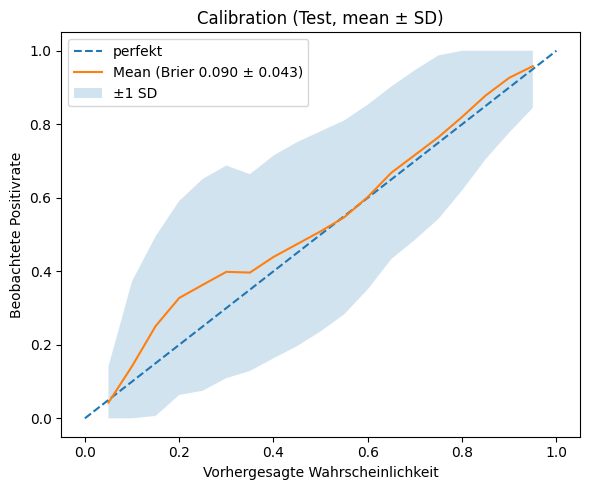

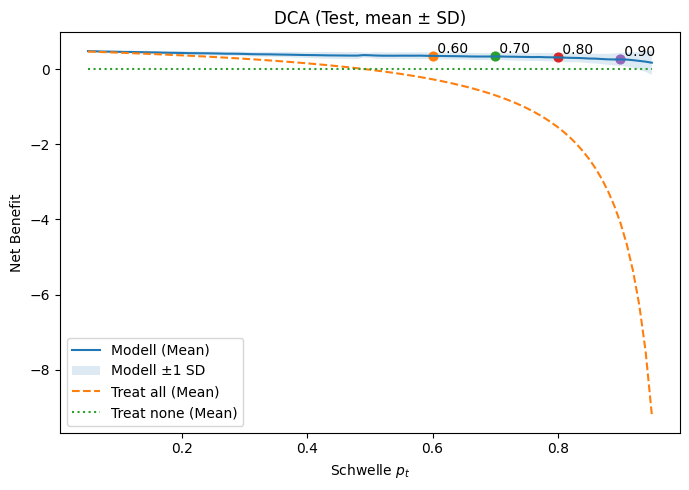


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.948 (0.936–0.960)
AUPRC: 0.941 (0.917–0.961)
Brier: 0.090 (0.079–0.102)

Fixed threshold (Youden on OOF): 0.493

Internal thresholded metrics at t=0.49 (Bootstrap 95% CIs)
Accuracy: 0.878 (0.859–0.897)
F1: 0.872 (0.850–0.894)
Precision: 0.900 (0.872–0.927)
Recall: 0.846 (0.815–0.877)

Calibration (point estimates):
  Intercept (CITL): 0.087
  Slope:            0.960
  Brier:            0.090


In [1]:
import os, warnings, argparse
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             accuracy_score, f1_score, precision_score, recall_score, roc_curve)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression as _LR

from scipy.stats import norm, chi2, t
from sklearn.covariance import LedoitWolf

import shap
shap.initjs()

# ====== Keras-Model (anpassbar) ==============================================
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

def create_model(n_features: int):
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(n_features,)),
        layers.Dense(64,  activation='relu'),
        layers.Dense(8,   activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


# ====== Copula-Augmentierung =================================================
def shrink_cov(Sigma, lam: float = 0.10):
    """Ridge-/Targeted-Shrinkage Richtung (avg_var * I)."""
    p = Sigma.shape[0]
    avg_var = np.trace(Sigma) / max(p, 1)
    Sigma_s = (1 - lam) * Sigma + lam * (avg_var * np.eye(p))
    return 0.5 * (Sigma_s + Sigma_s.T)

def sample_t_copula(mu, Sigma, n, nu=6, rng=None):
    """Multivariate t via Scale-Mixture; Rückgabe als Uniforms (t-CDF)."""
    rng = np.random.default_rng(rng)
    p = Sigma.shape[0]
    Z = rng.multivariate_normal(np.zeros(p), Sigma, size=n)     # ~ N(0,Sigma)
    w = chi2.rvs(df=nu, size=n, random_state=rng) / nu
    Tz = mu + Z / np.sqrt(w)[:, None]                           # ~ t_nu(mu,Sigma)
    U = t.cdf(Tz, df=nu)                                        # komponentenweise CDF
    return U

def gaussian_copula_augment(
    X_sub: pd.DataFrame,
    n_new: int,
    random_state=None,
    *,
    model: str = "gaussian",   # "gaussian" | "t"
    lam: float = 0.10,
    nu: int = 6
) -> pd.DataFrame:
    """Augmentiert X_sub per Copula: bewahrt Marginals & rangbasierte Abhängigkeiten."""
    rng = np.random.default_rng(random_state)

    Xn = X_sub.select_dtypes(include=[np.number])
    cols = Xn.columns.tolist()
    if len(cols) == 0 or len(Xn) < 2 or n_new <= 0:
        return pd.DataFrame(columns=Xn.columns)

    # Rang -> Uniform
    U = Xn.rank(pct=True, method='average').to_numpy()
    U = np.clip(U, 1e-6, 1 - 1e-6)
    # Uniform -> Z
    Z = norm.ppf(U)

    # Kovarianz + Shrinkage + kleiner Jitter
    lw = LedoitWolf().fit(Z)
    mu = Z.mean(axis=0)
    Sigma = lw.covariance_.copy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = shrink_cov(Sigma, lam=lam)
    Sigma += np.eye(Sigma.shape[0]) * 1e-6

    # Ziehen im Copula-Raum
    if model == "t":
        U_new = sample_t_copula(mu, Sigma, n_new, nu=nu, rng=rng)
    else:
        Z_new = rng.multivariate_normal(mu, Sigma, size=n_new)
        U_new = norm.cdf(Z_new)

    # inverse Marginals (empirische Quantile)
    X_new = np.empty_like(U_new)
    Xv = Xn.to_numpy()
    for j, col in enumerate(cols):
        col_vals = Xv[:, j]
        col_vals = np.nan_to_num(col_vals, nan=np.nanmedian(col_vals))
        if np.nanstd(col_vals) < 1e-12:
            X_new[:, j] = col_vals[0]
        else:
            X_new[:, j] = np.quantile(col_vals, U_new[:, j])
    return pd.DataFrame(X_new, columns=cols)

def augment_training_data_copula(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    target_size: int,
    random_state: int | None = None,
    *,
    model: str = "gaussian",
    lam: float = 0.10,
    nu: int = 6
):
    """Füllt bis target_size auf – proportional je Klasse. Rückgabe: (X_total, y_total, X_synth, y_synth)."""
    df = X_train.copy()
    # interne Funktionsvariante erwartet 'Verletzungsstatus' als Spaltenname
    y_train_named = y_train.rename("Verletzungsstatus")
    df["Verletzungsstatus"] = y_train_named.values

    X_train_r = X_train.reset_index(drop=True)
    y_train_r = y_train_named.reset_index(drop=True)

    need_total = max(0, target_size - len(X_train_r))
    if need_total == 0:
        return X_train_r, y_train_r, X_train_r.iloc[[]], y_train_r.iloc[[]]

    grp = df.groupby("Verletzungsstatus")
    props = grp.size() / len(df)

    synth_X_parts, synth_y_parts = [], []
    for cls, g in grp:
        need_cls = int(round(need_total * props.loc[cls]))
        if need_cls <= 0:
            continue
        Xg = g.drop(columns=["Verletzungsstatus"])
        X_new = gaussian_copula_augment(
            Xg, need_cls, random_state=random_state, model=model, lam=lam, nu=nu
        )
        y_new = pd.Series([cls] * len(X_new), name="Verletzungsstatus")
        synth_X_parts.append(X_new)
        synth_y_parts.append(y_new)

    if synth_X_parts:
        X_synth = pd.concat(synth_X_parts, axis=0).reset_index(drop=True)
        y_synth = pd.concat(synth_y_parts, axis=0).reset_index(drop=True)
    else:
        X_synth = X_train_r.iloc[[]]
        y_synth = y_train_r.iloc[[]]

    X_total = pd.concat([X_train_r, X_synth], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train_r, y_synth], axis=0).reset_index(drop=True)

    # ggf. Überschuss kürzen
    overshoot = len(X_total) - target_size
    if overshoot > 0 and len(X_synth) > 0:
        rng = np.random.default_rng(random_state)
        drop_idx = rng.choice(np.arange(len(X_synth)), size=overshoot, replace=False)
        mask = np.ones(len(X_synth), dtype=bool); mask[drop_idx] = False
        X_synth = X_synth.iloc[mask].reset_index(drop=True)
        y_synth = y_synth.iloc[mask].reset_index(drop=True)
        X_total = pd.concat([X_train_r, X_synth], axis=0).reset_index(drop=True)
        y_total = pd.concat([y_train_r, y_synth], axis=0).reset_index(drop=True)

    return X_total, y_total, X_synth, y_synth

# ====== Calibration & DCA Utilities ==========================================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (Test, mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def determine_fixed_threshold_youden(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

# ====== Hauptpipeline: CV + Copula + NN + SHAP ===============================
def run_ml_shap_with_copula_oof(
    data_path,
    target_column="Verletzungsstatus",
    *,
    cv_splits=5,
    cv_repeats=10,
    target_augmentation_multiplier=11,
    copula_model="t",       # "t" | "gaussian"
    copula_lam=0.15,
    copula_nu=10,
    random_state=42,
    shap_background_size=100,
    shap_nsamples=100,
    verbose=False,
    print_top_n=30,
    show_beeswarm=False,
    return_fold_curves=True
):
    df = pd.read_excel(data_path)
    if target_column not in df.columns:
        raise ValueError(f"'{target_column}' nicht in den Spalten.")
    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column]).select_dtypes(include=[np.number]).copy()
    if X.shape[1] == 0:
        raise ValueError("Keine numerischen Feature-Spalten gefunden.")

    cv = RepeatedStratifiedKFold(
        n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state
    )

    all_shap, all_Xs = [], []
    y_true_oof, p_pred_oof = [], []
    cal_list, dca_list = [], []

    print(f"\n=== ML+SHAP (Copula) : {os.path.basename(data_path)} ===")
    print(f"→ CV: {cv_splits}-Fold × {cv_repeats} Repeats")
    print(f"→ Augment: multiplier={target_augmentation_multiplier} | copula={copula_model} (lam={copula_lam}, nu={copula_nu})")
    print("→ SHAP über alle CV-Folds...")

    features = X.columns.tolist()
    exp_val = 0.0

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")

        X_tr, X_te = X.iloc[tr].reset_index(drop=True), X.iloc[te].reset_index(drop=True)
        y_tr, y_te = y.iloc[tr].reset_index(drop=True), y.iloc[te].reset_index(drop=True)

        # Copula-Augment NUR Training
        target_size = int(len(X_tr) * target_augmentation_multiplier)
        Xtr_aug, ytr_aug, _, _ = augment_training_data_copula(
            X_tr, y_tr,
            target_size=target_size,
            random_state=(random_state + fold),
            model=copula_model, lam=copula_lam, nu=copula_nu
        )

        # Skalierung
        scaler = MinMaxScaler()
        Xtr_s = pd.DataFrame(scaler.fit_transform(Xtr_aug), columns=Xtr_aug.columns).astype(np.float32)
        Xte_s = pd.DataFrame(scaler.transform(X_te),       columns=X_te.columns      ).astype(np.float32)

        Xtr_s.replace([np.inf,-np.inf], np.nan, inplace=True); Xtr_s.fillna(0, inplace=True)
        Xte_s.replace([np.inf,-np.inf], np.nan, inplace=True); Xte_s.fillna(0, inplace=True)

        # NN trainieren
        model = create_model(Xtr_s.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(Xtr_s, ytr_aug.values, validation_split=0.2, epochs=100, batch_size=16, callbacks=[es], verbose=0)

        # Vorhersagen
        p_te = model.predict(Xte_s, verbose=0).flatten()
        y_true_oof.append(y_te.values)
        p_pred_oof.append(p_te)

        # Pro-Fold Calibration & DCA
        cal_list.append(compute_calibration(y_te.values, p_te, n_bins=10))
        dca_list.append(decision_curve(y_te.values, p_te, thresholds=np.linspace(0.05,0.95,91)))

        # SHAP (KernelExplainer, logit-Link)
        f = lambda x: model.predict(np.nan_to_num(x.astype(np.float32)), verbose=0).flatten()
        bg = Xtr_s.sample(n=min(shap_background_size, len(Xtr_s)), random_state=(random_state + fold)).values
        expl = shap.KernelExplainer(f, bg, link="logit")
        sv = expl.shap_values(Xte_s.values, nsamples=shap_nsamples)
        sv = np.nan_to_num(sv, nan=0.0, posinf=0.0, neginf=0.0)
        if sv.shape != Xte_s.shape:
            raise RuntimeError(f"[Fold {fold}] SHAP shape mismatch: {sv.shape} vs {Xte_s.shape}")

        all_shap.append(sv)
        all_Xs.append(Xte_s.values)
        exp_val = float(np.atleast_1d(expl.expected_value)[0])

    # OOF-Stacks
    shap_stack = np.vstack(all_shap)
    X_stack    = np.vstack(all_Xs)
    y_true_oof = np.concatenate(y_true_oof)
    p_pred_oof = np.concatenate(p_pred_oof)

    # SHAP-Topliste
    print("\nSHAP-Wertprüfung (OOF):")
    print(f"  Min={np.min(shap_stack):.4f} | Max={np.max(shap_stack):.4f} | Mean={np.mean(shap_stack):.6f}")
    print(f"  NaN={np.isnan(shap_stack).sum()} | Inf={np.isinf(shap_stack).sum()}")

    mean_shaps     = shap_stack.mean(axis=0)
    abs_mean_shaps = np.abs(mean_shaps)
    order = np.argsort(abs_mean_shaps)[::-1]
    top = min(print_top_n, len(order))

    print(f"\nTop {top} Features (nach |mean SHAP|, OOF):")
    for i in order[:top]:
        print(f"{features[i]:<50} {mean_shaps[i]: .6f}")

    if show_beeswarm:
        try:
            shap.summary_plot(shap_stack, features=X_stack, feature_names=features, show=True)
        except Exception as e:
            print(f"[Beeswarm] Plot nicht möglich: {e}")

    out = dict(
        features=features,
        shap_stack=shap_stack,
        X_stack=X_stack,
        expected_value=exp_val,
        y_true_oof=y_true_oof,
        p_pred_oof=p_pred_oof,
        config=dict(
            cv_splits=cv_splits, cv_repeats=cv_repeats,
            target_augmentation_multiplier=target_augmentation_multiplier,
            copula_model=copula_model, copula_lam=copula_lam, copula_nu=copula_nu,
            shap_background_size=shap_background_size, shap_nsamples=shap_nsamples,
            random_state=random_state
        )
    )
    if return_fold_curves:
        out["cal_list"] = cal_list
        out["dca_list"] = dca_list
    return out

# ====== Reporting Helper =====================================================
def report_internal_oof(res, n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    # 1) Plots (ganz am Anfang)
    cal_agg = aggregate_calibration(res["cal_list"], grid=np.linspace(0.05, 0.95, 19))
    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    dca_agg = aggregate_dca(res["dca_list"], grid=np.linspace(0.05, 0.95, 91))
    plot_dca_mean(dca_agg, mark_pts=dca_marks, title="DCA (Test, mean ± SD)")

    # 2) OOF-CIs
    y_true_oof = res["y_true_oof"]; p_pred_oof = res["p_pred_oof"]
    oof_ci = bootstrap_ci_internal_oof(y_true_oof, p_pred_oof, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    # 3) Youden-Schwelle
    thr = determine_fixed_threshold_youden(y_true_oof, p_pred_oof)
    print(f"\nFixed threshold (Youden on OOF): {thr:.3f}")

    # 4) Thresholded Metriken @ thr
    th_ci = bootstrap_ci_thresholded(y_true_oof, p_pred_oof, thr=thr, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={thr:.2f} (Bootstrap 95% CIs)", th_ci)

    # 5) Kalibration (Punkt-Schätzer auf OOF)
    I,S,B = calibration_intercept_slope(y_true_oof, p_pred_oof)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

# ====== MAIN ================================================================
def main():
    ap = argparse.ArgumentParser(description="Copula-CV mit NN, OOF-SHAP, Calibration & DCA")
    ap.add_argument("--data", default=r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Basistabelle_5_bis_14_PostOP\Basistabelle_5_bis_14_PostOP.xlsx", help="Pfad zur Excel-Datei mit Verletzungstatus als Zielvariable")
    ap.add_argument("--target", default="Verletzungsstatus")
    ap.add_argument("--cv_splits", type=int, default=5)
    ap.add_argument("--cv_repeats", type=int, default=10)
    ap.add_argument("--augment_mult", type=int, default=11)
    ap.add_argument("--copula_model", choices=["t","gaussian"], default="t")
    ap.add_argument("--copula_lam", type=float, default=0.15)
    ap.add_argument("--copula_nu", type=int, default=10)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--beeswarm", action="store_true")
    args, _ = ap.parse_known_args()

    res = run_ml_shap_with_copula_oof(
        data_path=args.data,
        target_column=args.target,
        cv_splits=args.cv_splits,
        cv_repeats=args.cv_repeats,
        target_augmentation_multiplier=args.augment_mult,
        copula_model=args.copula_model,
        copula_lam=args.copula_lam,
        copula_nu=args.copula_nu,
        random_state=args.seed,
        show_beeswarm=args.beeswarm
    )

    # Ausgabe: Plots + gewünschte Kennzahlen
    report_internal_oof(res, n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])

if __name__ == "__main__":
    main()


Dieser Codeblock erstellt **zwei gut lesbare SHAP-Zusammenfassungsplots** auf Basis bereits berechneter SHAP-Ergebnisse:

- verwendet die im Objekt `res` gespeicherten **Features, SHAP-Werte und Testdaten**,
- berechnet pro Feature den **signed mean SHAP** über alle Samples,
- sortiert die Features nach dem **Betrag des mittleren SHAP-Effekts**,
- wählt die **Top-N wichtigsten Features** aus,
- erstellt einen **Beeswarm/Violin-SHAP-Plot** in fester, konsistenter Reihenfolge,
- erstellt zusätzlich einen **horizontalen Balkenplot** mit dem **signed mean SHAP**,
- färbt dabei **positive Effekte blau** und **negative Effekte rot**,
- und optimiert beide Abbildungen für **große, gut lesbare Labels und klare Darstellung**.

Ziel ist eine **saubere, publikationsnahe Visualisierung der wichtigsten SHAP-Features** mit konsistenter Reihenfolge und interpretierbarer Richtung des Effekts.

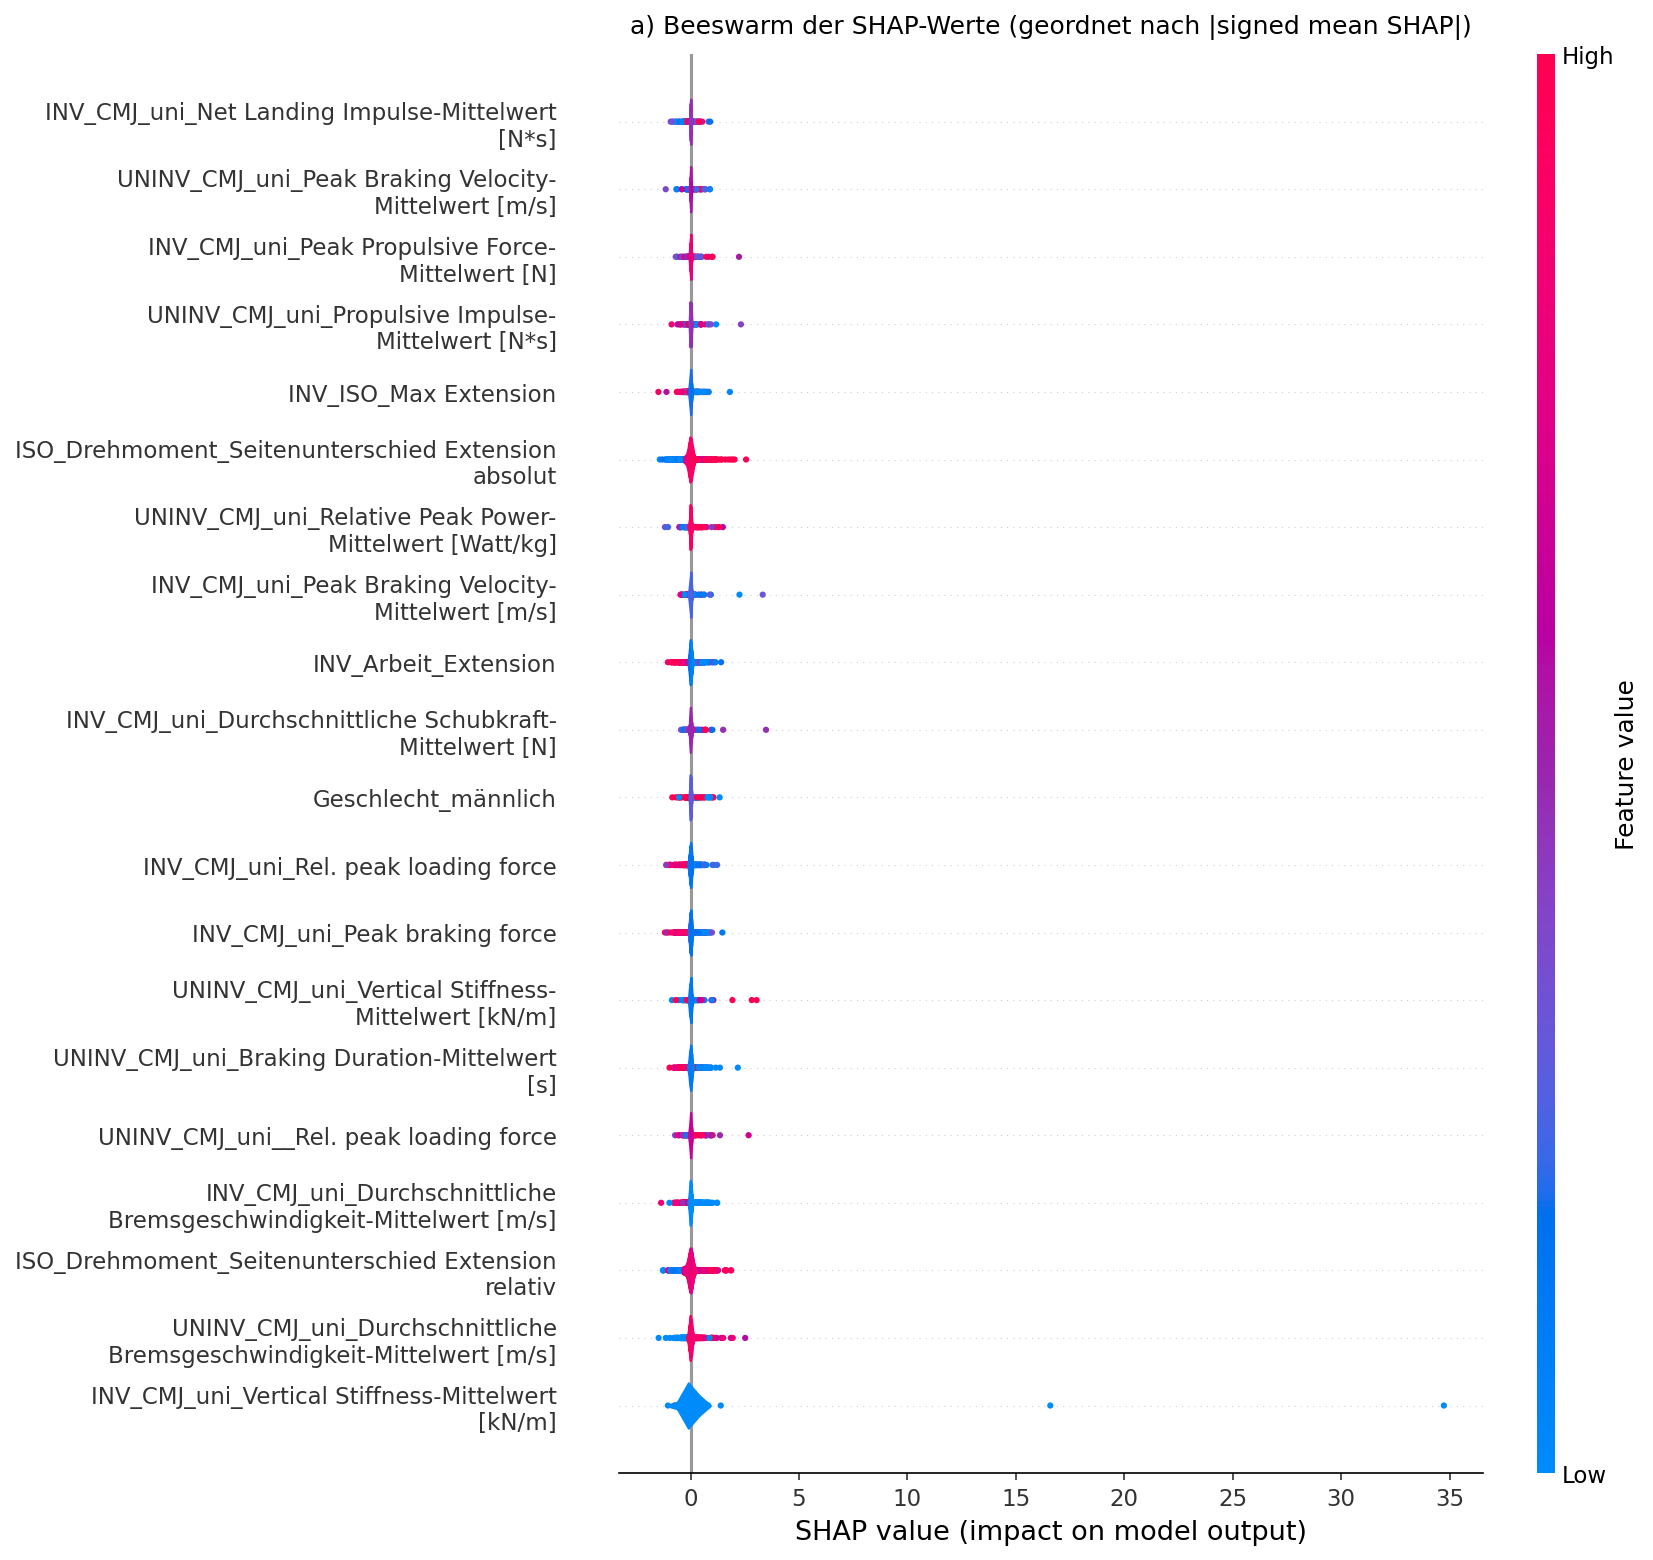

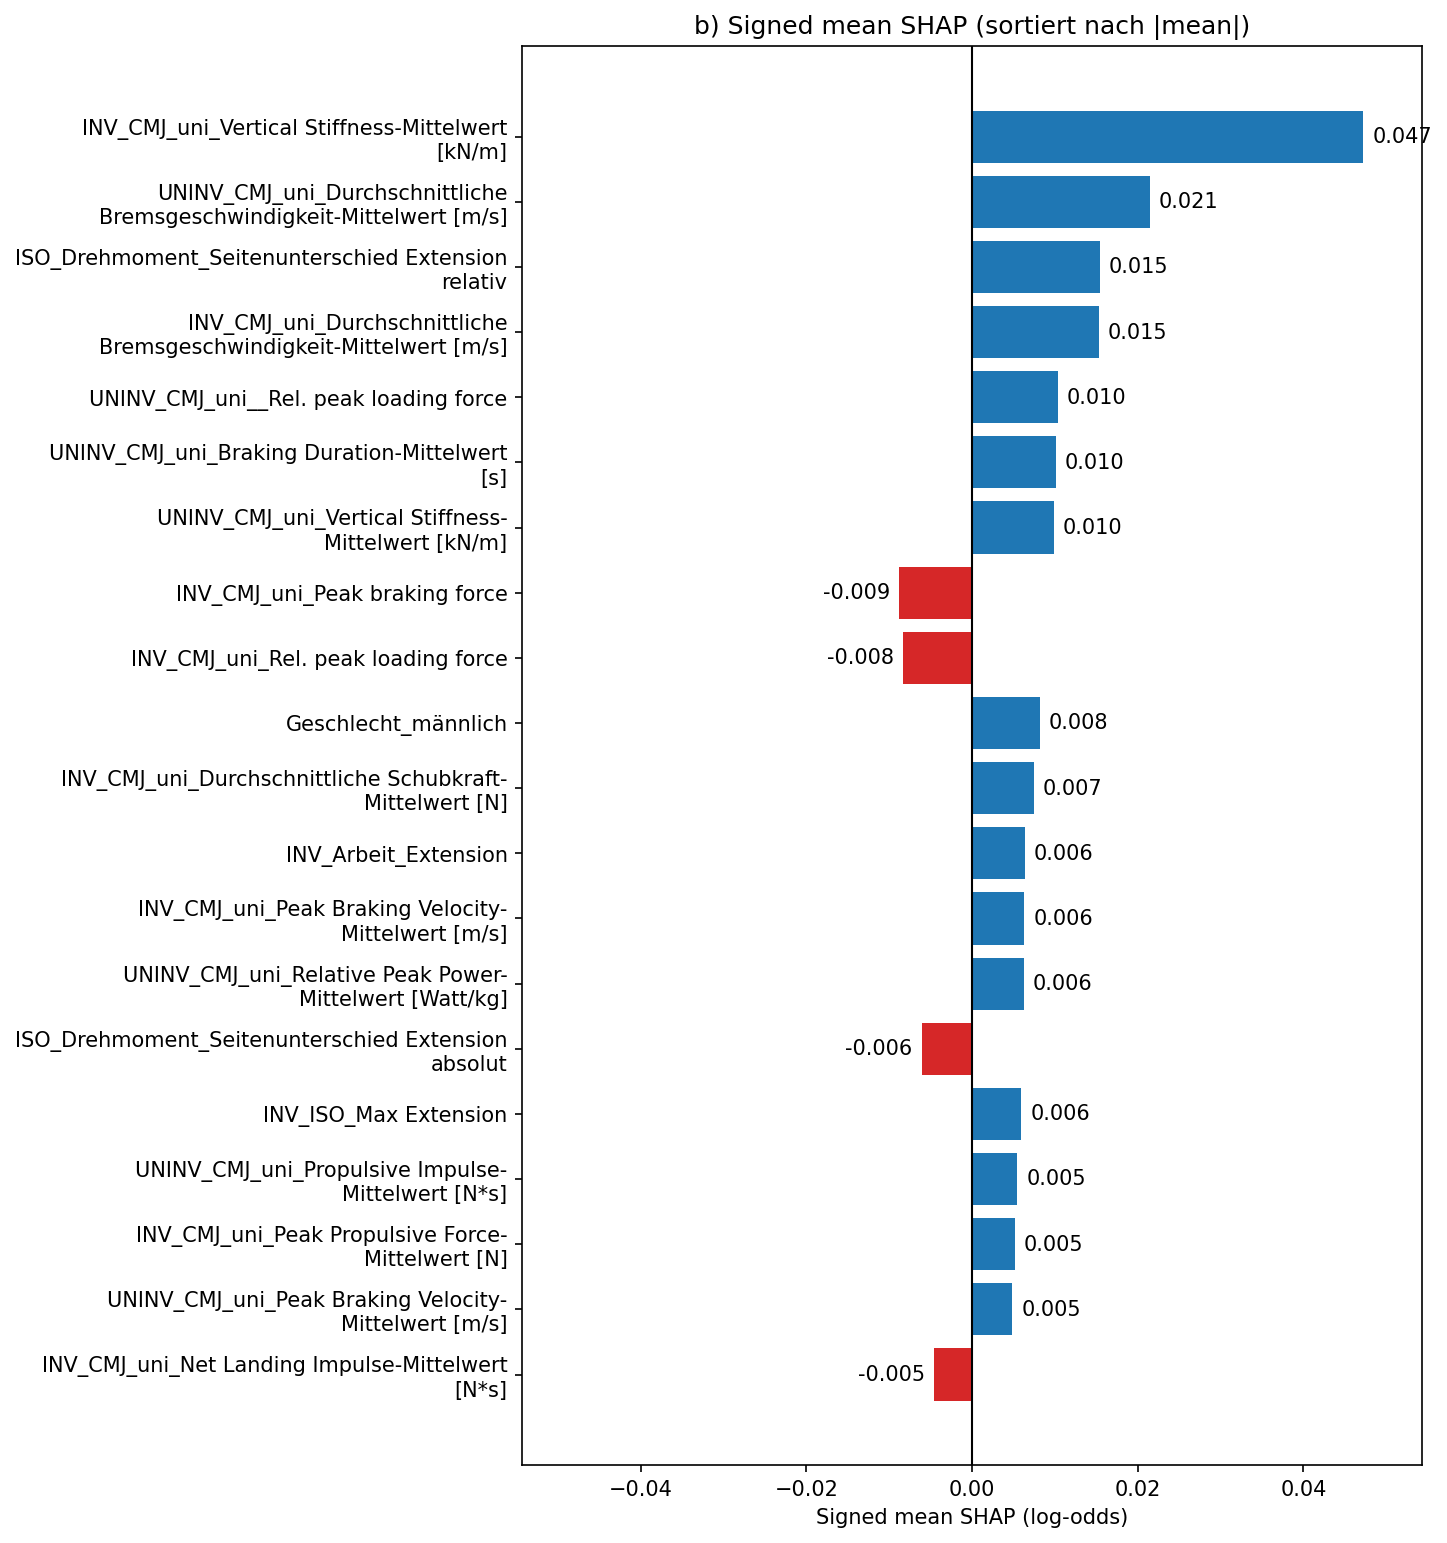

In [4]:
# === Signed-mean-SHAP: konsistente Reihenfolge + große, gut lesbare Plots ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, textwrap, shap

# --- erwartet: res aus deinem Run ---
features   = res["features"]
shap_stack = res["shap_stack"]   # (n_samples, n_features)
X_stack    = res["X_stack"]

# --- Parameter für Darstellung ---
TOP_N      = 20        # wie viele Features zeigen
WRAP       = 42        # Label-Umbruchbreite
DPI        = 150
BEE_W      = 12.0
BEE_H      = max(6.0, 0.45 * TOP_N + 2.0)   # dynamische Höhe
BAR_W      = 10.0
BAR_H      = BEE_H
LEFT_MARGIN= 0.36      # mehr Platz für lange Y-Labels

# 1) signed mean SHAP berechnen und sortieren (nach Betrag, Anzeige mit Vorzeichen)
mean_signed = shap_stack.mean(axis=0)  # <-- signed mean
df_dir = (
    pd.DataFrame({"Feature": features, "signed_mean": mean_signed})
      .assign(abs_signed=lambda d: d["signed_mean"].abs())
      .sort_values("abs_signed", ascending=False)
      .head(TOP_N)
      .reset_index(drop=True)
)

# Index-Reihenfolgen für beide Plots (Balken: Top oben; Beeswarm: Top oben)
idx_map    = {f: i for i, f in enumerate(features)}
order_bar  = np.array([idx_map[f] for f in df_dir["Feature"].tolist()])      # [top ... low]
order_bee  = order_bar[::-1]   # shap.summary_plot malt von unten nach oben -> drehen, damit Top oben steht

# Y-Labels weich umbrechen (Beeswarm braucht gedrehte Reihenfolge)
wrapped_bee = [textwrap.fill(features[i], width=WRAP) for i in order_bee]
wrapped_bar = [textwrap.fill(f, width=WRAP) for f in df_dir["Feature"].tolist()]

# =======================
# FIGURE 1: Beeswarm (ordnung fix, groß & luftig)
# =======================
plt.rcParams["figure.dpi"] = DPI
plt.figure(figsize=(BEE_W, BEE_H))

shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_bee,
    plot_type="violin",
    max_display=len(order_bee),
    sort=False,            # WICHTIG: unsere Reihenfolge beibehalten
    color_bar=True,
    show=False,
    plot_size=None         # Größe steuern wir über figsize/adjust
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=LEFT_MARGIN, right=0.96, top=0.94, bottom=0.08)
plt.title("a) Beeswarm der SHAP-Werte (geordnet nach |signed mean SHAP|)", pad=10)
plt.show()

# =======================
# FIGURE 2: Balken (signed mean, gleiche Reihenfolge wie im Text/top-first)
# =======================
vals = df_dir["signed_mean"].to_numpy()
yt   = np.arange(len(vals))

fig, ax = plt.subplots(figsize=(BAR_W, BAR_H), dpi=DPI)
colors = np.where(vals >= 0, "#1f77b4", "#d62728")  # + blau, − rot
ax.barh(yt, vals, color=colors)
ax.set_yticks(yt)
ax.set_yticklabels(wrapped_bar)
ax.invert_yaxis()  # größte oben
ax.axvline(0, color='k', lw=1)
ax.set_xlabel("Signed mean SHAP (log-odds)")
ax.set_title("b) Signed mean SHAP (sortiert nach |mean|)")

# symmetrische x-Achse und dezente Labels
xmax = float(np.max(np.abs(vals))) if len(vals) else 1.0
ax.set_xlim(-1.15*xmax, 1.15*xmax)
pad = 0.02 * (1.15*xmax)
for yi, v in enumerate(vals):
    ax.text(v + (pad if v >= 0 else -pad), yi, f"{v:.3f}",
            va="center", ha=("left" if v>=0 else "right"))

plt.gcf().subplots_adjust(left=LEFT_MARGIN, right=0.96, top=0.94, bottom=0.08)
plt.show()

# Optional: speichern
# plt.savefig("shap_beeswarm_signedmean.png", dpi=300, bbox_inches="tight")
# fig.savefig("shap_signedmean_bar.png", dpi=300, bbox_inches="tight")
